# **Análise dos Indicadores Econômicos do Brasil — 2015 a 2024**

# 1. Introdução

Esse projeto tem como objetivo analisar a evolução dos principais indicadores
econômicos brasileiros entre 2015 e 2024.

O projeto busca investigar a evolução dos indicadores, identificar períodos
de crescimento e crise, comparar variáveis econômicas e analisar possíveis
relações entre elas.

*Utilizaremos recursos de análise exploratória, limpeza de dados,
engenharia de atributos, cálculo de KPIs, visualização e análise estatística.*


## 2. Contextualização econômica

Os indicadores econômicos permitem acompanhar o comportamento da economia
ao longo do tempo.

Neste projeto serão analisadas as informações presentes na base fornecida,
considerando o período de 2015 a 2024.

O período é relevante por incluir diferentes cenários econômicos brasileiros,
como a recessão de 2015–2016, a recuperação econômica posterior, os efeitos
da pandemia de Covid-19 em 2020 e a recuperação observada nos anos seguintes.

A análise dos indicadores permitirá observar como variáveis relacionadas à
atividade econômica, inflação, mercado de trabalho, juros, câmbio, renda e
consumo se comportaram ao longo do período.


# 3. Explicação da base

In [75]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# 4. Leitura dos dados

In [76]:
df = pd.read_csv("simulacao_indicadores_economicos_brasil.csv")

display(df.head())

,ano,trimestre,data,pib,inflacao,taxa_juros,taxa_desemprego,cambio_dolar,renda_media,consumo_familias,investimento,exportacoes,importacoes,nivel_economico
0,2015,1,2015-03-01,"2,013,242.64",7.29,10.81,5.21,5.82,"3,077.70",92.81,93.19,486.01,180.73,Crise
1,2015,2,2015-06-01,"1,825,371.98",6.97,7.76,9.32,4.41,"4,081.32",114.84,106.41,368.69,352.33,Crise
2,2015,3,2015-09-01,"2,584,505.76",4.80,3.41,8.47,5.29,"3,510.61",132.22,121.50,492.67,292.00,Estabilidade
3,2015,4,2015-12-01,"2,501,214.10",9.74,5.50,11.24,5.06,"3,987.57",96.94,110.15,438.43,395.98,Crise
4,2016,1,2016-03-01,"1,848,504.55",3.01,7.79,10.33,5.60,"3,980.34",118.20,126.46,197.97,273.79,Crescimento


In [77]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Conhecendo a base**

In [78]:
print("Dimensões da base:")
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Dimensões da base:
Linhas: 40
Colunas: 14


In [79]:
print("Colunas disponíveis:")
print(df.columns.tolist())

Colunas disponíveis:
['ano', 'trimestre', 'data', 'pib', 'inflacao', 'taxa_juros', 'taxa_desemprego', 'cambio_dolar', 'renda_media', 'consumo_familias', 'investimento', 'exportacoes', 'importacoes', 'nivel_economico']


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ano               40 non-null     int64  
 1   trimestre         40 non-null     int64  
 2   data              40 non-null     object 
 3   pib               40 non-null     float64
 4   inflacao          40 non-null     float64
 5   taxa_juros        40 non-null     float64
 6   taxa_desemprego   40 non-null     float64
 7   cambio_dolar      40 non-null     float64
 8   renda_media       40 non-null     float64
 9   consumo_familias  40 non-null     float64
 10  investimento      40 non-null     float64
 11  exportacoes       40 non-null     float64
 12  importacoes       40 non-null     float64
 13  nivel_economico   40 non-null     object 
dtypes: float64(10), int64(2), object(2)
memory usage: 4.5+ KB


In [81]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ano,40.00,NaN,NaN,NaN,"2,019.50",2.91,"2,015.00","2,017.00","2,019.50","2,022.00","2,024.00"
trimestre,40.00,NaN,NaN,NaN,2.50,1.13,1.00,1.75,2.50,3.25,4.00
data,40,40,2015-03-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pib,40.00,NaN,NaN,NaN,"2,273,106.48","346,694.93","1,707,970.94","1,956,975.34","2,287,032.97","2,592,124.10","2,777,415.79"
inflacao,40.00,NaN,NaN,NaN,6.56,2.95,2.21,4.10,6.47,9.12,11.90
taxa_juros,40.00,NaN,NaN,NaN,9.33,3.66,3.32,6.13,8.61,12.18,15.91
taxa_desemprego,40.00,NaN,NaN,NaN,9.28,2.98,5.04,7.24,8.66,11.18,14.91
cambio_dolar,40.00,NaN,NaN,NaN,4.58,0.84,3.08,3.91,4.62,5.29,5.99
renda_media,40.00,NaN,NaN,NaN,"2,865.28",738.97,"1,815.15","2,118.18","3,038.10","3,481.99","4,081.32"
consumo_familias,40.00,NaN,NaN,NaN,112.33,17.11,80.19,98.47,113.81,125.72,139.48


In [82]:
display(df.head(10))


,ano,trimestre,data,pib,inflacao,taxa_juros,taxa_desemprego,cambio_dolar,renda_media,consumo_familias,investimento,exportacoes,importacoes,nivel_economico
0,2015,1,2015-03-01,"2,013,242.64",7.29,10.81,5.21,5.82,"3,077.70",92.81,93.19,486.01,180.73,Crise
1,2015,2,2015-06-01,"1,825,371.98",6.97,7.76,9.32,4.41,"4,081.32",114.84,106.41,368.69,352.33,Crise
2,2015,3,2015-09-01,"2,584,505.76",4.80,3.41,8.47,5.29,"3,510.61",132.22,121.50,492.67,292.00,Estabilidade
3,2015,4,2015-12-01,"2,501,214.10",9.74,5.50,11.24,5.06,"3,987.57",96.94,110.15,438.43,395.98,Crise
4,2016,1,2016-03-01,"1,848,504.55",3.01,7.79,10.33,5.60,"3,980.34",118.20,126.46,197.97,273.79,Crescimento
5,2016,2,2016-06-01,"2,554,501.28",9.06,4.41,8.72,4.80,"2,474.86",121.28,92.94,417.90,176.49,Crescimento
6,2016,3,2016-09-01,"2,777,415.79",11.74,8.06,11.16,5.61,"2,195.64",98.13,125.12,215.40,435.31,Estabilidade
7,2016,4,2016-12-01,"1,885,614.95",4.77,14.79,9.01,5.60,"3,546.48",132.12,87.47,355.92,410.76,Crescimento
8,2017,1,2017-03-01,"2,637,819.42",6.72,8.20,8.57,5.52,"2,503.72",105.09,118.99,432.05,217.18,Crise
9,2017,2,2017-06-01,"2,706,716.68",9.15,6.05,6.12,3.43,"2,729.20",103.68,114.13,467.35,327.48,Crise


**Verificação dos anos**

In [83]:
print("Valores encontrados na coluna ano:")

if "ano" in df.columns:
    print(sorted(df["ano"].dropna().unique()))
else:
    print("A coluna 'ano' não foi encontrada.")

Valores encontrados na coluna ano:
[np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


# 5. Limpeza e Preparação

In [84]:
df = df.copy()

In [85]:
print("Valores ausentes por coluna:")

display(
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame("valores_ausentes")
)

Valores ausentes por coluna:


,valores_ausentes
ano,0
trimestre,0
data,0
pib,0
inflacao,0
taxa_juros,0
taxa_desemprego,0
cambio_dolar,0
renda_media,0
consumo_familias,0


In [86]:
ausentes = pd.DataFrame({
    "quantidade": df.isnull().sum(),
    "percentual": df.isnull().mean() * 100
})

display(ausentes.sort_values("percentual", ascending=False))

,quantidade,percentual
ano,0,0.00
trimestre,0,0.00
data,0,0.00
pib,0,0.00
inflacao,0,0.00
taxa_juros,0,0.00
taxa_desemprego,0,0.00
cambio_dolar,0,0.00
renda_media,0,0.00
consumo_familias,0,0.00


In [87]:
print("Quantidade de linhas duplicadas:", df.duplicated().sum())

Quantidade de linhas duplicadas: 0


In [88]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dimensões após remoção de duplicidades:", df.shape)

Dimensões após remoção de duplicidades: (40, 14)


**Tratamento das colunas numéricas**

In [89]:
for coluna in df.columns:
    if coluna != "ano":
        df[coluna] = pd.to_numeric(
            df[coluna],
            errors="ignore"
        )

/tmp/ipykernel_727/1334197594.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[coluna] = pd.to_numeric(


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ano               40 non-null     int64  
 1   trimestre         40 non-null     int64  
 2   data              40 non-null     object 
 3   pib               40 non-null     float64
 4   inflacao          40 non-null     float64
 5   taxa_juros        40 non-null     float64
 6   taxa_desemprego   40 non-null     float64
 7   cambio_dolar      40 non-null     float64
 8   renda_media       40 non-null     float64
 9   consumo_familias  40 non-null     float64
 10  investimento      40 non-null     float64
 11  exportacoes       40 non-null     float64
 12  importacoes       40 non-null     float64
 13  nivel_economico   40 non-null     object 
dtypes: float64(10), int64(2), object(2)
memory usage: 4.5+ KB


In [91]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
ano,40.00,"2,019.50",2.91,"2,015.00","2,017.00","2,019.50","2,022.00","2,024.00"
trimestre,40.00,2.50,1.13,1.00,1.75,2.50,3.25,4.00
pib,40.00,"2,273,106.48","346,694.93","1,707,970.94","1,956,975.34","2,287,032.97","2,592,124.10","2,777,415.79"
inflacao,40.00,6.56,2.95,2.21,4.10,6.47,9.12,11.90
taxa_juros,40.00,9.33,3.66,3.32,6.13,8.61,12.18,15.91
taxa_desemprego,40.00,9.28,2.98,5.04,7.24,8.66,11.18,14.91
cambio_dolar,40.00,4.58,0.84,3.08,3.91,4.62,5.29,5.99
renda_media,40.00,"2,865.28",738.97,"1,815.15","2,118.18","3,038.10","3,481.99","4,081.32"
consumo_familias,40.00,112.33,17.11,80.19,98.47,113.81,125.72,139.48
investimento,40.00,106.60,13.38,79.49,95.22,107.97,116.25,126.46


# 6. Engenharia de atributos

In [92]:
if "ano" in df.columns:
    df["ano"] = pd.to_numeric(df["ano"], errors="coerce")
    df = df.sort_values("ano").reset_index(drop=True)

**Variações anuais**

In [93]:
colunas_numericas = df.select_dtypes(include=np.number).columns.tolist()

if "ano" in colunas_numericas:
    colunas_numericas.remove("ano")

for coluna in colunas_numericas:
    df[f"{coluna}_variacao"] = df[coluna].pct_change() * 100

In [94]:
display(df.head())

,ano,trimestre,data,pib,inflacao,taxa_juros,taxa_desemprego,cambio_dolar,renda_media,consumo_familias,investimento,exportacoes,importacoes,nivel_economico,trimestre_variacao,pib_variacao,inflacao_variacao,taxa_juros_variacao,taxa_desemprego_variacao,cambio_dolar_variacao,renda_media_variacao,consumo_familias_variacao,investimento_variacao,exportacoes_variacao,importacoes_variacao
0,2015,1,2015-03-01,"2,013,242.64",7.29,10.81,5.21,5.82,"3,077.70",92.81,93.19,486.01,180.73,Crise,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,2,2015-06-01,"1,825,371.98",6.97,7.76,9.32,4.41,"4,081.32",114.84,106.41,368.69,352.33,Crise,100.00,-9.33,-4.39,-28.21,78.89,-24.23,32.61,23.74,14.19,-24.14,94.95
2,2015,3,2015-09-01,"2,584,505.76",4.80,3.41,8.47,5.29,"3,510.61",132.22,121.50,492.67,292.00,Estabilidade,50.00,41.59,-31.13,-56.06,-9.12,19.95,-13.98,15.13,14.18,33.63,-17.12
3,2015,4,2015-12-01,"2,501,214.10",9.74,5.50,11.24,5.06,"3,987.57",96.94,110.15,438.43,395.98,Crise,33.33,-3.22,102.92,61.29,32.70,-4.35,13.59,-26.68,-9.34,-11.01,35.61
4,2016,1,2016-03-01,"1,848,504.55",3.01,7.79,10.33,5.60,"3,980.34",118.20,126.46,197.97,273.79,Crescimento,-75.00,-26.10,-69.10,41.64,-8.10,10.67,-0.18,21.93,14.81,-54.85,-30.86


**Identificação dos indicadores disponíveis**

In [95]:
print("Indicadores encontrados na base:\n")

for coluna in df.columns:
    print("-", coluna)

Indicadores encontrados na base:

- ano
- trimestre
- data
- pib
- inflacao
- taxa_juros
- taxa_desemprego
- cambio_dolar
- renda_media
- consumo_familias
- investimento
- exportacoes
- importacoes
- nivel_economico
- trimestre_variacao
- pib_variacao
- inflacao_variacao
- taxa_juros_variacao
- taxa_desemprego_variacao
- cambio_dolar_variacao
- renda_media_variacao
- consumo_familias_variacao
- investimento_variacao
- exportacoes_variacao
- importacoes_variacao


# 7. KPIs

In [96]:
def encontrar_coluna(possiveis_nomes, colunas):
    for coluna in colunas:
        coluna_normalizada = coluna.lower().strip()

        for nome in possiveis_nomes:
            if nome in coluna_normalizada:
                return coluna

    return None

In [97]:
coluna_pib = encontrar_coluna(
    ["pib"],
    df.columns
)

coluna_inflacao = encontrar_coluna(
    ["inflacao", "inflação", "ipca"],
    df.columns
)

coluna_desemprego = encontrar_coluna(
    ["desemprego", "desocupacao", "desocupação"],
    df.columns
)

coluna_juros = encontrar_coluna(
    ["juros", "selic"],
    df.columns
)

coluna_dolar = encontrar_coluna(
    ["dolar", "dólar", "cambio", "câmbio"],
    df.columns
)

coluna_crescimento = encontrar_coluna(
    ["crescimento", "pib_crescimento", "crescimento_pib"],
    df.columns
)

**Cálculo dos KPIs**

In [98]:
kpis = {}

In [99]:
if coluna_pib:
    kpis["PIB médio"] = df[coluna_pib].mean()

if coluna_inflacao:
    kpis["Inflação média"] = df[coluna_inflacao].mean()

if coluna_desemprego:
    kpis["Taxa média de desemprego"] = df[coluna_desemprego].mean()

if coluna_juros:
    kpis["Taxa média de juros"] = df[coluna_juros].mean()

if coluna_dolar:
    kpis["Cotação média do dólar"] = df[coluna_dolar].mean()

if coluna_crescimento:
    kpis["Crescimento econômico médio"] = df[coluna_crescimento].mean()
elif coluna_pib:
    # Caso o crescimento esteja representado pelo próprio PIB
    kpis["Crescimento econômico médio"] = df[coluna_pib].pct_change().mean() * 100

In [100]:
kpis_df = pd.DataFrame(
    list(kpis.items()),
    columns=["KPI", "Valor"]
)

display(kpis_df)

,KPI,Valor
0,PIB médio,"2,273,106.48"
1,Inflação média,6.56
2,Taxa média de desemprego,9.28
3,Taxa média de juros,9.33
4,Cotação média do dólar,4.58
5,Crescimento econômico médio,2.15


# Evolução temporal dos indicadores
**PIB**

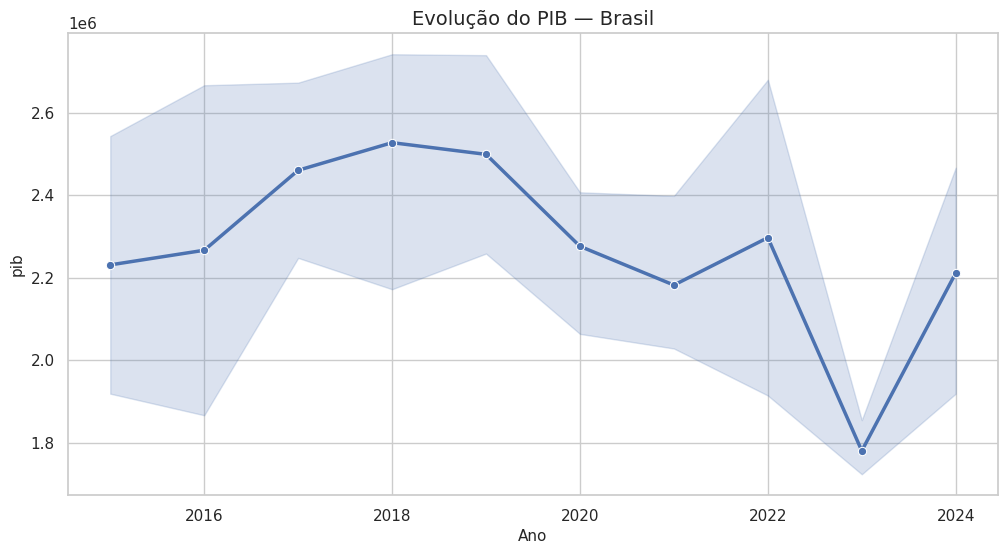

In [101]:
if coluna_pib and "ano" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=df,
        x="ano",
        y=coluna_pib,
        marker="o",
        linewidth=2.5
    )

    plt.title("Evolução do PIB — Brasil")
    plt.xlabel("Ano")
    plt.ylabel(coluna_pib)

    plt.show()

**Inflação**

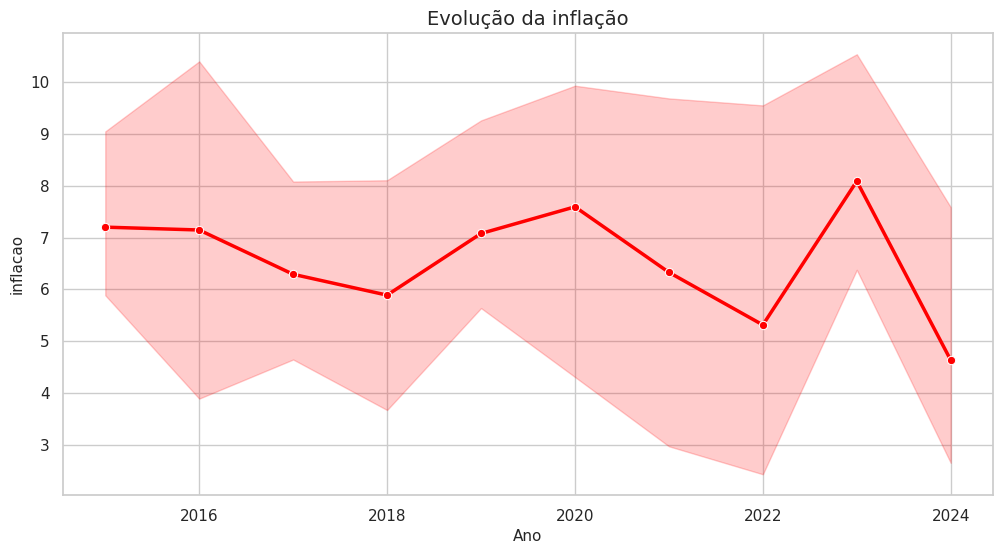

In [102]:
if coluna_inflacao and "ano" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=df,
        x="ano",
        y=coluna_inflacao,
        marker="o",
        color="red",
        linewidth=2.5
    )

    plt.title("Evolução da inflação")
    plt.xlabel("Ano")
    plt.ylabel(coluna_inflacao)

    plt.show()

**Desemprego**

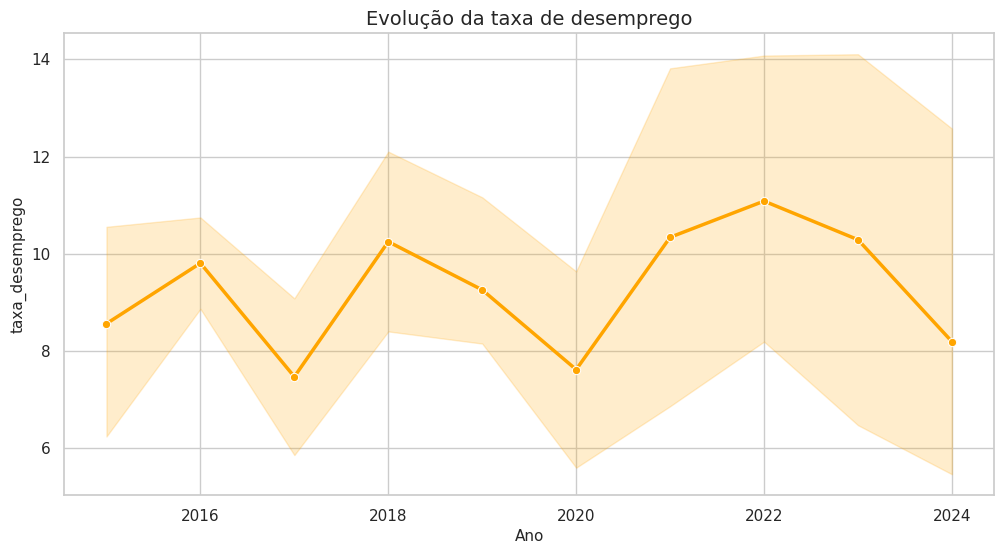

In [103]:
if coluna_desemprego and "ano" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=df,
        x="ano",
        y=coluna_desemprego,
        marker="o",
        color="orange",
        linewidth=2.5
    )

    plt.title("Evolução da taxa de desemprego")
    plt.xlabel("Ano")
    plt.ylabel(coluna_desemprego)

    plt.show()

**Juros**

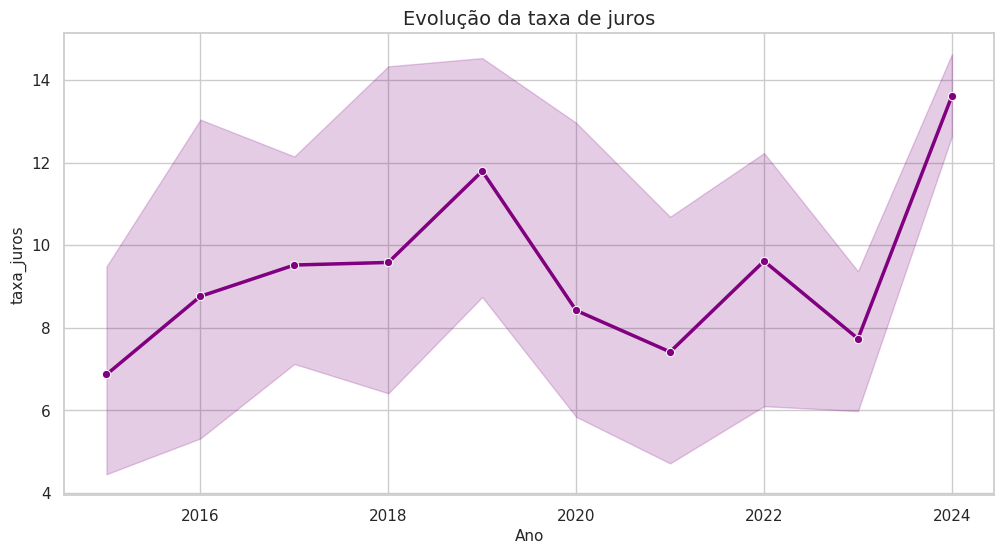

In [104]:
if coluna_juros and "ano" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=df,
        x="ano",
        y=coluna_juros,
        marker="o",
        color="purple",
        linewidth=2.5
    )

    plt.title("Evolução da taxa de juros")
    plt.xlabel("Ano")
    plt.ylabel(coluna_juros)

    plt.show()

**Dólar**

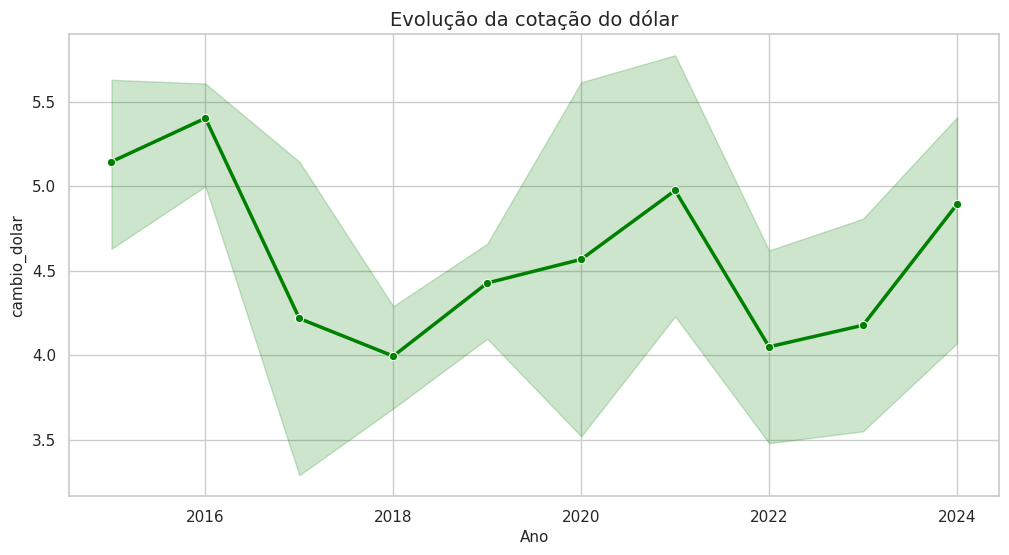

In [105]:
if coluna_dolar and "ano" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=df,
        x="ano",
        y=coluna_dolar,
        marker="o",
        color="green",
        linewidth=2.5
    )

    plt.title("Evolução da cotação do dólar")
    plt.xlabel("Ano")
    plt.ylabel(coluna_dolar)

    plt.show()


# 8. Visualização
**1 - Relação entre inflação e desemprego**

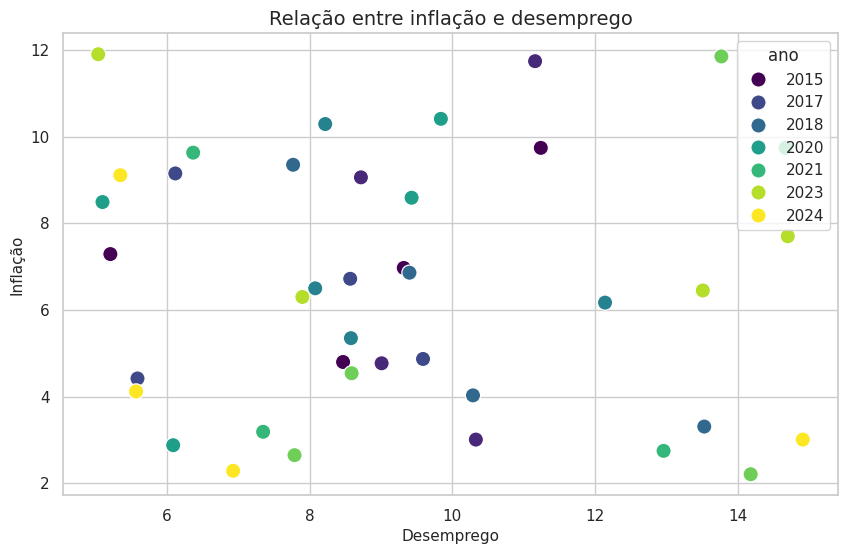

In [106]:
if coluna_inflacao and coluna_desemprego:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x=coluna_desemprego,
        y=coluna_inflacao,
        hue="ano" if "ano" in df.columns else None,
        s=120,
        palette="viridis"
    )

    plt.title("Relação entre inflação e desemprego")
    plt.xlabel("Desemprego")
    plt.ylabel("Inflação")

    plt.show()

**Correlação**

In [107]:
if coluna_inflacao and coluna_desemprego:

    correlacao = df[
        [coluna_inflacao, coluna_desemprego]
    ].corr()

    display(correlacao)

,inflacao,taxa_desemprego
inflacao,1.00,-0.08
taxa_desemprego,-0.08,1.00


In [108]:
if coluna_inflacao and coluna_desemprego:

    valor_correlacao = df[
        coluna_inflacao
    ].corr(
        df[coluna_desemprego]
    )

    print(
        f"Correlação entre inflação e desemprego: "
        f"{valor_correlacao:.2f}"
    )

Correlação entre inflação e desemprego: -0.08


**2 - Relação entre juros e consumo**

In [109]:
coluna_consumo = encontrar_coluna(
    ["consumo"],
    df.columns
)

print("Coluna de consumo:", coluna_consumo)

Coluna de consumo: consumo_familias


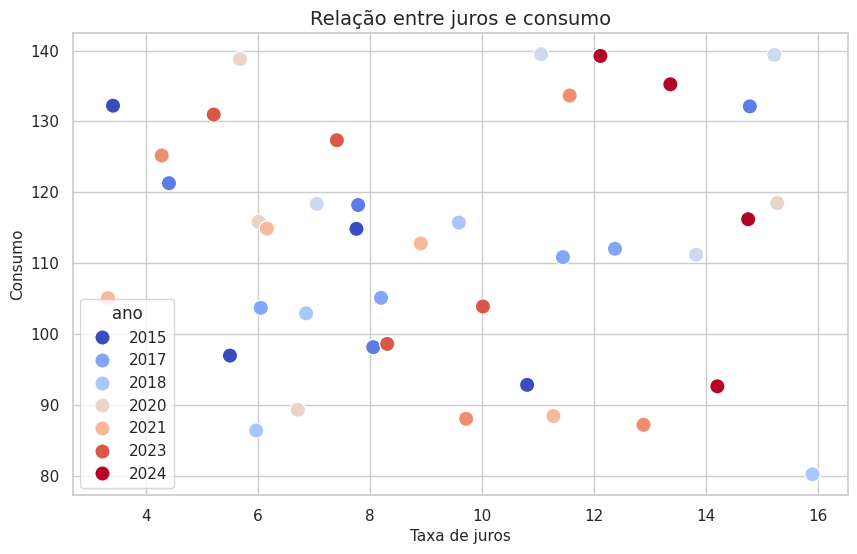

In [110]:
if coluna_juros and coluna_consumo:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x=coluna_juros,
        y=coluna_consumo,
        hue="ano" if "ano" in df.columns else None,
        s=120,
        palette="coolwarm"
    )

    plt.title("Relação entre juros e consumo")
    plt.xlabel("Taxa de juros")
    plt.ylabel("Consumo")

    plt.show()

In [111]:
if coluna_juros and coluna_consumo:

    correlacao_juros_consumo = df[
        coluna_juros
    ].corr(
        df[coluna_consumo]
    )

    print(
        f"Correlação entre juros e consumo: "
        f"{correlacao_juros_consumo:.2f}"
    )

Correlação entre juros e consumo: -0.02


**Correlação**

In [112]:
if coluna_juros and coluna_consumo:

    correlacao_juros_consumo = df[
        coluna_juros
    ].corr(
        df[coluna_consumo]
    )

    print(
        f"Correlação entre juros e consumo: "
        f"{correlacao_juros_consumo:.2f}"
    )

Correlação entre juros e consumo: -0.02


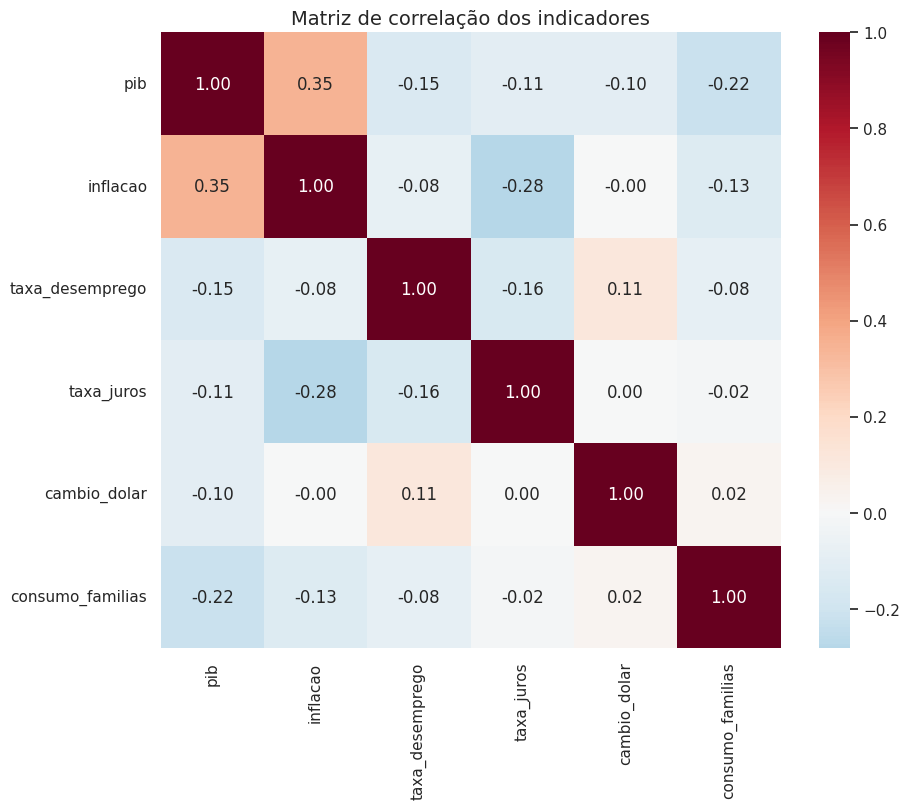

In [113]:
colunas_para_correlacao = [
    coluna for coluna in [
        coluna_pib,
        coluna_inflacao,
        coluna_desemprego,
        coluna_juros,
        coluna_dolar,
        coluna_consumo
    ]
    if coluna is not None
]

correlacoes = df[colunas_para_correlacao].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlacoes,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)

plt.title("Matriz de correlação dos indicadores")

plt.show()

In [114]:
desvios = df[
    colunas_para_correlacao
].std().sort_values(ascending=False)

display(
    desvios.to_frame("Desvio padrão")
)

,Desvio padrão
pib,"346,694.93"
consumo_familias,17.11
taxa_juros,3.66
taxa_desemprego,2.98
inflacao,2.95
cambio_dolar,0.84


## 9.1 Interpretação

O desvio padrão será utilizado para identificar quais indicadores apresentaram
maior variabilidade ao longo do período analisado.

Quanto maior o desvio padrão, maior foi a oscilação da variável em relação à
sua média.


**Identificação dos períodos críticos**

In [115]:
if coluna_crescimento is None and coluna_pib:

    df["crescimento_calculado"] = (
        df[coluna_pib].pct_change() * 100
    )

    periodos_criticos = df[
        df["crescimento_calculado"] < 0
    ]

    display(
        periodos_criticos[
            ["ano", "crescimento_calculado"]
        ]
    )

,ano,crescimento_calculado
1,2015,-9.33
3,2015,-3.22
4,2016,-26.10
7,2016,-32.11
10,2017,-18.93
13,2018,-3.04
14,2018,-25.58
16,2019,-11.87
18,2019,-20.29
20,2020,-14.53


**Ano de maior crescimento**

In [116]:
coluna_analise_crescimento = (
    coluna_crescimento
    if coluna_crescimento
    else "crescimento_calculado"
)

if coluna_analise_crescimento in df.columns:

    maior_crescimento = df.loc[
        df[coluna_analise_crescimento].idxmax()
    ]

    print(
        "Ano de maior crescimento:",
        maior_crescimento["ano"]
    )

    print(
        "Valor:",
        maior_crescimento[coluna_analise_crescimento]
    )

Ano de maior crescimento: 2015
Valor: 41.587894868420186


**Ano de maior queda**

In [117]:
if coluna_analise_crescimento in df.columns:

    maior_queda = df.loc[
        df[coluna_analise_crescimento].idxmin()
    ]

    print(
        "Ano de maior queda:",
        maior_queda["ano"]
    )

    print(
        "Valor:",
        maior_queda[coluna_analise_crescimento]
    )

Ano de maior queda: 2016
Valor: -32.10901454549591


**Ranking dos anos**

In [118]:
if coluna_analise_crescimento in df.columns:

    ranking = df[
        ["ano", coluna_analise_crescimento]
    ].sort_values(
        coluna_analise_crescimento,
        ascending=False
    )

    display(ranking)

,ano,crescimento_calculado
2,2015,41.59
8,2017,39.89
5,2016,38.19
30,2022,34.35
15,2018,32.38
19,2019,25.38
37,2024,23.99
22,2020,23.90
12,2018,20.44
17,2019,17.41


**Comparação dos indicadores**

In [119]:
df_normalizado = df.copy()

for coluna in colunas_para_correlacao:

    minimo = df_normalizado[coluna].min()
    maximo = df_normalizado[coluna].max()

    if maximo != minimo:

        df_normalizado[coluna] = (
            (df_normalizado[coluna] - minimo)
            / (maximo - minimo)
        )

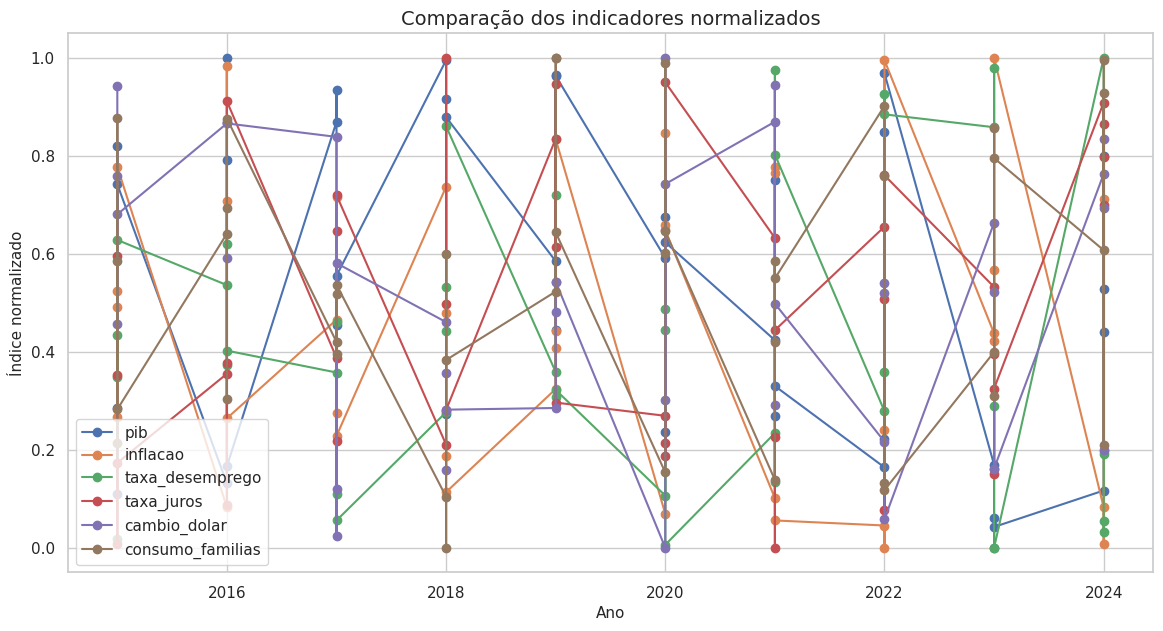

In [120]:
plt.figure(figsize=(14, 7))

for coluna in colunas_para_correlacao:

    plt.plot(
        df_normalizado["ano"],
        df_normalizado[coluna],
        marker="o",
        label=coluna
    )

plt.title("Comparação dos indicadores normalizados")
plt.xlabel("Ano")
plt.ylabel("Índice normalizado")
plt.legend()

plt.show()

**Evolução da renda média**

In [121]:
coluna_renda = encontrar_coluna(
    ["renda", "rendimento"],
    df.columns
)

print("Coluna de renda encontrada:", coluna_renda)

Coluna de renda encontrada: renda_media


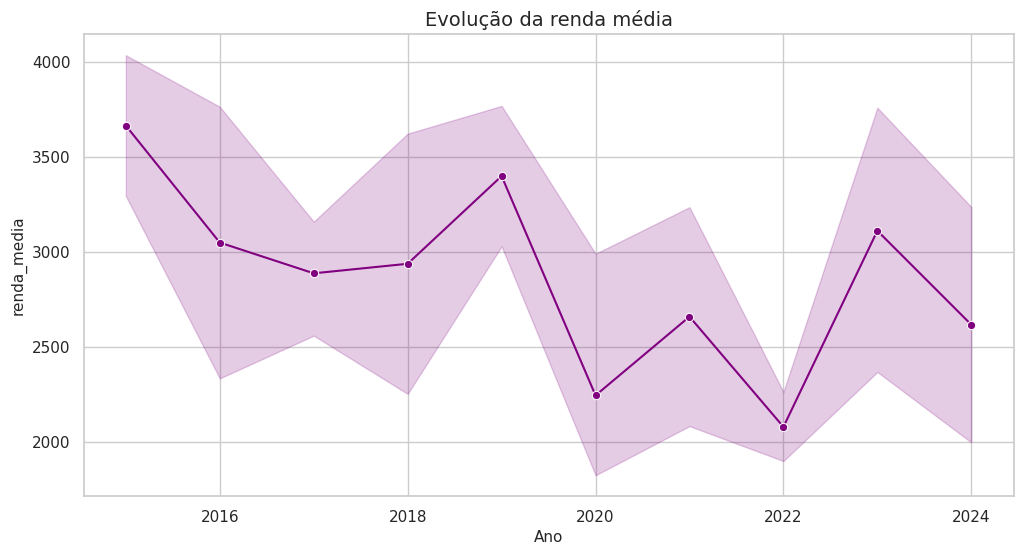

In [122]:
if coluna_renda and "ano" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=df,
        x="ano",
        y=coluna_renda,
        marker="o",
        color="purple"
    )

    plt.title("Evolução da renda média")
    plt.xlabel("Ano")
    plt.ylabel(coluna_renda)

    plt.show()

**Dashboard final dos KPIs**

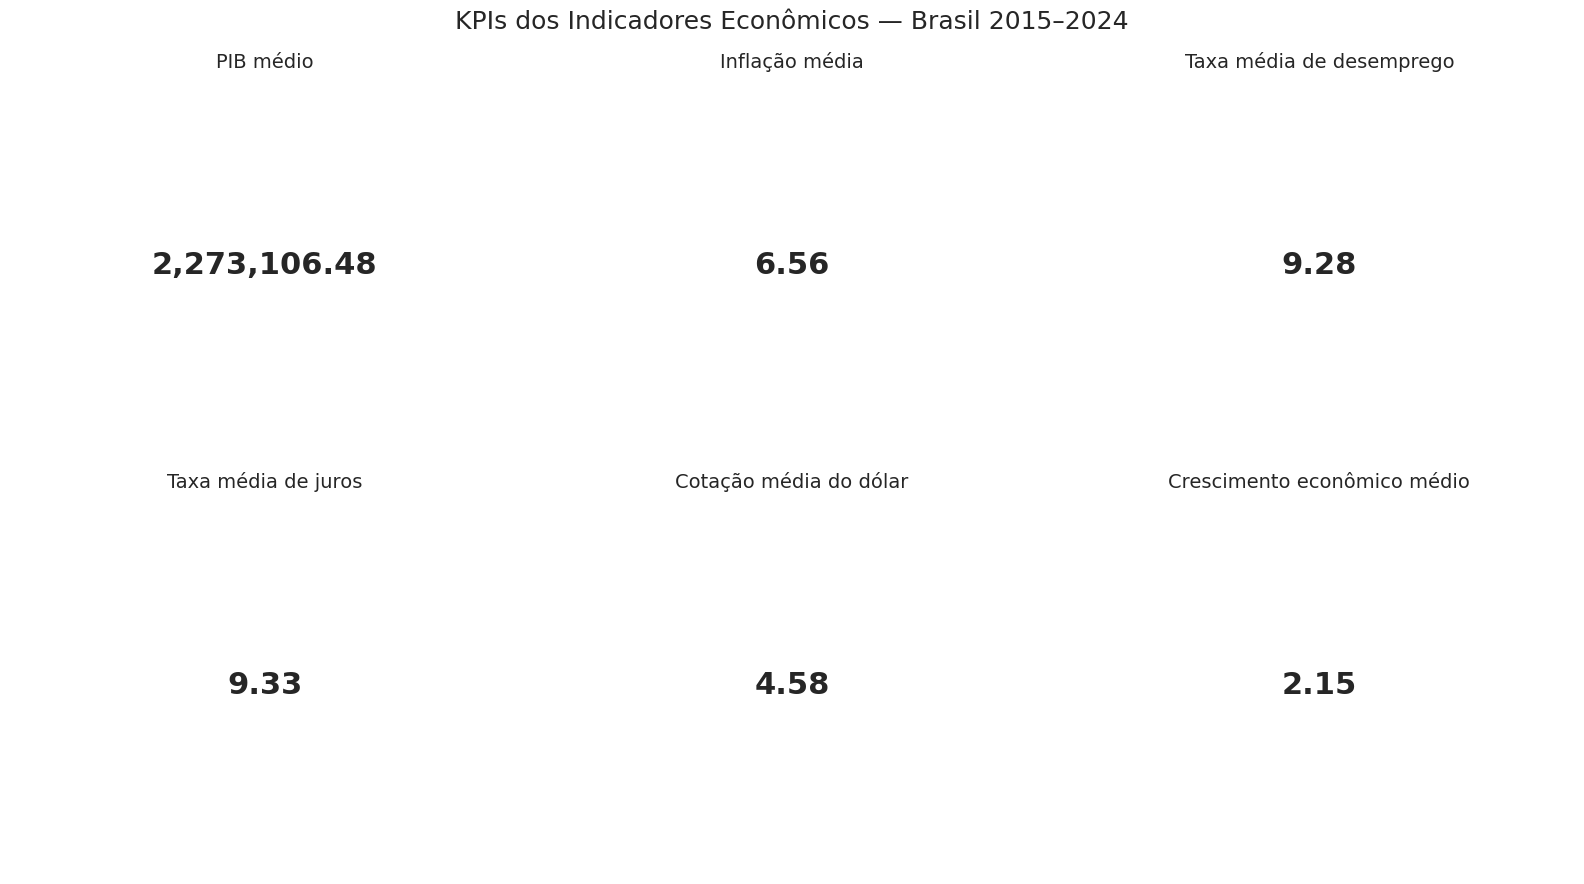

In [123]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9)
)

axes = axes.flatten()

for i, (nome, valor) in enumerate(kpis.items()):

    axes[i].text(
        0.5,
        0.5,
        f"{valor:,.2f}",
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )

    axes[i].set_title(nome)
    axes[i].axis("off")

plt.suptitle(
    "KPIs dos Indicadores Econômicos — Brasil 2015–2024",
    fontsize=18
)

plt.tight_layout()

plt.show()

#9.2 Interpretação dos resultados

A análise exploratória permite observar o comportamento dos indicadores
econômicos brasileiros ao longo do período de 2015 a 2024.

A evolução do PIB permite identificar os momentos de expansão e retração
econômica. Os anos em que o crescimento apresentou valores negativos devem
ser considerados períodos de contração da atividade econômica.

A análise da inflação permite identificar os períodos de maior pressão sobre
os preços. Já a taxa de desemprego possibilita observar o comportamento do
mercado de trabalho ao longo do período.

A comparação entre inflação e desemprego permite investigar a existência de
uma associação entre as duas variáveis. Entretanto, uma correlação estatística
não deve ser interpretada como prova de causalidade.

A relação entre juros e consumo também é analisada por meio de gráfico de
dispersão e coeficiente de correlação. Taxas de juros mais elevadas podem
afetar o custo do crédito e, consequentemente, o consumo, mas essa relação
também sofre influência de renda, emprego, inflação, expectativas e outras
variáveis econômicas.

A análise do câmbio permite verificar os períodos de maior valorização ou
desvalorização do real em relação ao dólar.

Por fim, o desvio padrão dos indicadores permite identificar quais variáveis
apresentaram maior instabilidade durante o período analisado.


# 10. Conclusão

O presente projeto analisou os principais indicadores econômicos brasileiros
entre 2015 e 2024 utilizando a base
`simulacao_indicadores_economicos_brasil.csv`.

A partir das etapas de leitura, limpeza, preparação, engenharia de atributos,
cálculo de KPIs e visualização, foi possível estruturar uma visão integrada
do comportamento da economia brasileira.

Os resultados permitem avaliar a evolução do PIB, inflação, desemprego,
taxa de juros, câmbio, renda e consumo, além de identificar períodos de maior
crescimento, retração e instabilidade.

As análises de correlação também possibilitam investigar relações entre
variáveis, especialmente entre inflação e desemprego e entre juros e consumo.

É importante destacar que correlação não implica necessariamente causalidade.
As relações observadas devem ser interpretadas considerando o contexto
econômico de cada período e a influência de outras variáveis.

Dessa forma, a análise demonstra como ferramentas de ciência de dados podem
ser utilizadas para transformar uma base de indicadores econômicos em
informações úteis para compreender tendências e mudanças na economia
brasileira.
